In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [12]:
df = pd.read_csv('nandinip/homework9/noisy_curvefit_data.csv')

In [14]:
print(df.shape)
print(df.head())
print(df.tail())

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


C:\Users\nandi\AppData\Local\Temp\ipykernel_8772\3236947123.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


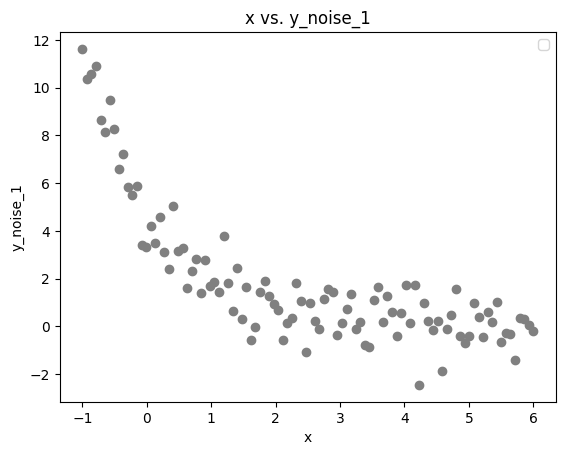

In [18]:
plt.scatter(df['x'], df['y_noise_1'], color='gray')
plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.title('x vs. y_noise_1')
plt.legend()
plt.show()

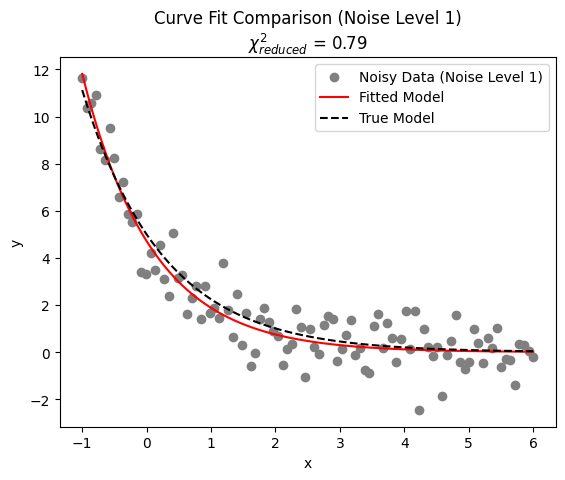

In [21]:
x = df['x']
y_noise_1 = df['y_noise_1']

def model(x, A, k):
    return A*np.exp(-k*x)

p0 = [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

plt.scatter(x, y_noise_1, color='gray', label='Noisy Data (Noise Level 1)')
y_fitted = model(x, A_fit, k_fit)
plt.plot(x, y_fitted, color='red', label='Fitted Model')
y_true = model(x, 5, 0.8)
plt.plot(x, y_true, color='black', linestyle='--', label='True Model')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f"Curve Fit Comparison (Noise Level 1)\n$\chi^2_{{reduced}}$ = {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [22]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced

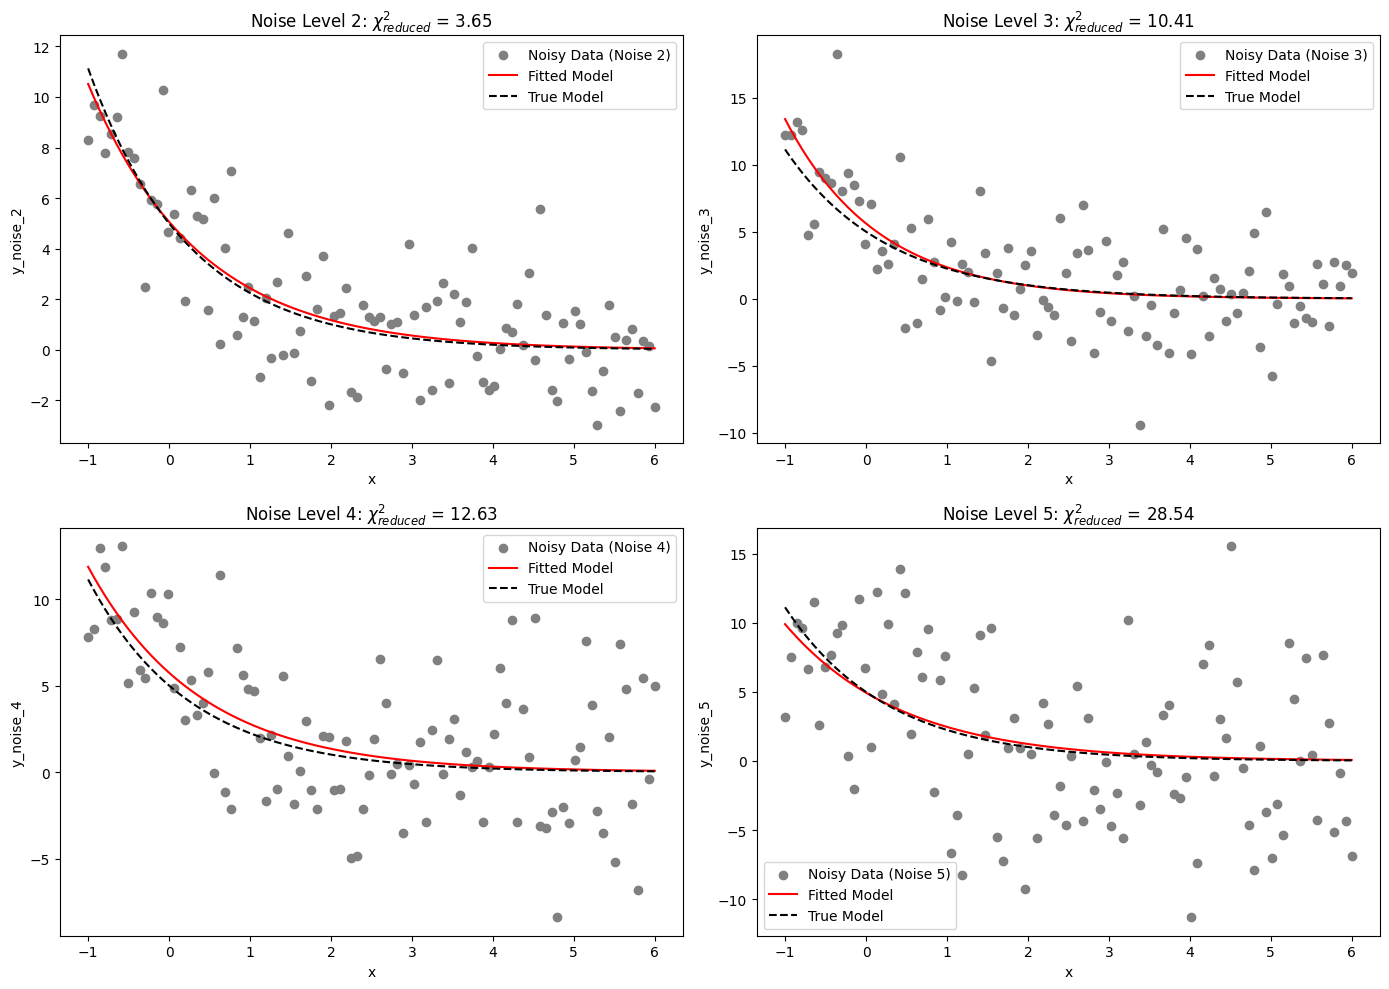

In [25]:
y_columns = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))
axes = axes.flatten()

for i, col_name in enumerate(y_columns):
    y_data = df[col_name]
    noise_level = int(col_name.split('_')[-1])
    A_fit, k_fit, chi2_reduced = fit_model(x, y_data)
    
    ax = axes[i]
    ax.scatter(x, y_data, color='gray', label=f"Noisy Data (Noise {noise_level})")
    y_fitted = model(x, A_fit, k_fit)
    ax.plot(x, y_fitted, color='red', label='Fitted Model')
    y_true = model(x, 5, 0.8)
    ax.plot(x, y_true, color='black', linestyle='--', label='True Model')
    
    ax.set_title(f"Noise Level {noise_level}: $\chi^2_{{reduced}}$ = {chi2_reduced:.2f}")
    ax.set_xlabel('x')
    ax.set_ylabel(col_name)
    ax.legend()

plt.tight_layout()
plt.show()

- The red and black dotted lines end up being not as close to the actual shape of the data, because of the increased randomness of the points (more noise)
- The reduced chi-squared increases with noise level

In [26]:
noise_levels = []
A_fits = []
k_fits = []
chi2_reduced_values = []

all_y_columns = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

for col_name in all_y_columns:
    y_data = df[col_name]
    
    A_fit, k_fit, chi2_reduced = fit_model(x, y_data) 
    
    noise_levels.append(col_name)
    A_fits.append(A_fit)
    k_fits.append(k_fit)
    chi2_reduced_values.append(chi2_reduced)

results_df = pd.DataFrame({'Noise level': noise_levels, 'A fit': A_fits, 'k fit': k_fits, 'Reduced chi-squared': chi2_reduced_values})
results_df.to_csv("noisy_parameters.csv", index=False)